# GC Example 07: Central Velocity Dispersion

**EPS Research — Milky Way GC Corpus v1.3.2**

Central velocity dispersion sigma_0 from Baumgardt N-body models.
Relates to cluster mass via sigma_0^2 ∝ M/r_hm.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Clusters with sigma_0: 154
sigma_0 range: 0.2 -- 33.1 km/s


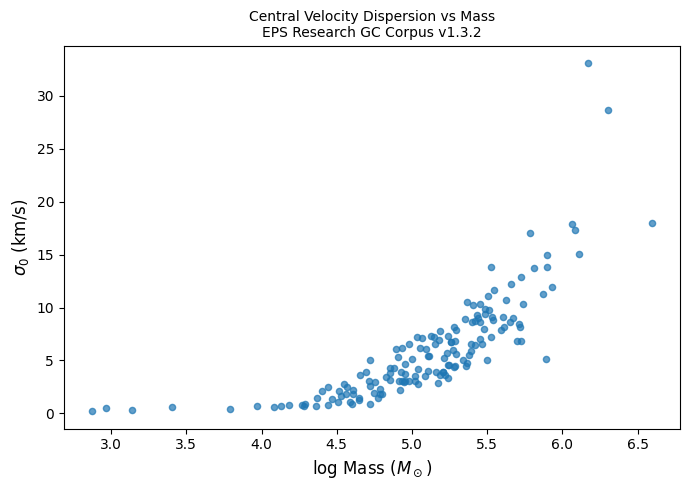

In [3]:
data=[(c['cluster_id'],c['baumgardt2023']['sigma0_kms'],c['baumgardt2023']['mass_msun'])
      for c in clusters if c.get('baumgardt2023') and c['baumgardt2023'].get('sigma0_kms')]
sigma=[d[1] for d in data]; mass=[d[2] for d in data]
print(f"Clusters with sigma_0: {len(data)}")
print(f"sigma_0 range: {min(sigma):.1f} -- {max(sigma):.1f} km/s")
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(np.log10(mass),sigma,s=20,alpha=0.7,color='#1f77b4')
ax.set_xlabel(r'log Mass ($M_\odot$)',fontsize=12); ax.set_ylabel(r'$\sigma_0$ (km/s)',fontsize=12)
ax.set_title('Central Velocity Dispersion vs Mass\nEPS Research GC Corpus v1.3.2',fontsize=10)
plt.tight_layout(); plt.savefig('gc07_sigma0.png',dpi=150,bbox_inches='tight'); plt.show()